In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")

In [10]:
df=pd.read_csv("/content/solar_power_output.csv")
df.head()

,temperature,humidity,solar_irradiance,wind_speed,solar_power_output
0,19.363503,75.852937,266.619636,5.190818,128.101772
1,33.767858,62.887709,587.710853,4.791819,290.911789
2,28.299849,44.762209,885.651252,0.256421,442.336390
3,24.966462,85.103602,759.002398,3.412478,380.261988
4,13.900466,74.778494,825.905033,3.801956,415.931953


data collection

In [11]:
df.head()

,temperature,humidity,solar_irradiance,wind_speed,solar_power_output
0,19.363503,75.852937,266.619636,5.190818,128.101772
1,33.767858,62.887709,587.710853,4.791819,290.911789
2,28.299849,44.762209,885.651252,0.256421,442.336390
3,24.966462,85.103602,759.002398,3.412478,380.261988
4,13.900466,74.778494,825.905033,3.801956,415.931953


head is used to retrive teh last 5 value
tail is used to give last five values


In [12]:
df.tail()

,temperature,humidity,solar_irradiance,wind_speed,solar_power_output
495,18.833806,27.326566,701.391519,6.569552,352.480220
496,24.591403,93.385086,657.541311,9.566146,326.834297
497,11.943366,30.945490,517.144639,0.689580,259.133251
498,34.359870,96.018988,441.807202,0.570547,223.778239
499,34.655269,55.680462,877.000285,2.821871,435.410369


In [13]:
df.shape

(500, 5)

shape is used to tell the no of rows and column present in the data table


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   temperature         500 non-null    float64
 1   humidity            500 non-null    float64
 2   solar_irradiance    500 non-null    float64
 3   wind_speed          500 non-null    float64
 4   solar_power_output  500 non-null    float64
dtypes: float64(5)
memory usage: 19.7 KB


info function is used to give teh

In [15]:
df.describe().round(2)

,temperature,humidity,solar_irradiance,wind_speed,solar_power_output
count,500.00,500.00,500.00,500.00,500.00
mean,22.46,58.56,565.80,4.96,283.30
std,7.47,22.84,267.47,2.87,133.84
min,10.13,20.37,104.45,0.03,46.83
25%,16.03,38.33,317.11,2.41,158.41
50%,22.83,57.75,585.76,5.09,290.50
75%,28.90,78.11,799.61,7.37,402.00
max,34.82,99.98,999.47,9.98,502.22


exploratory data analysis(EDA)
here we will be checking the data visialisation

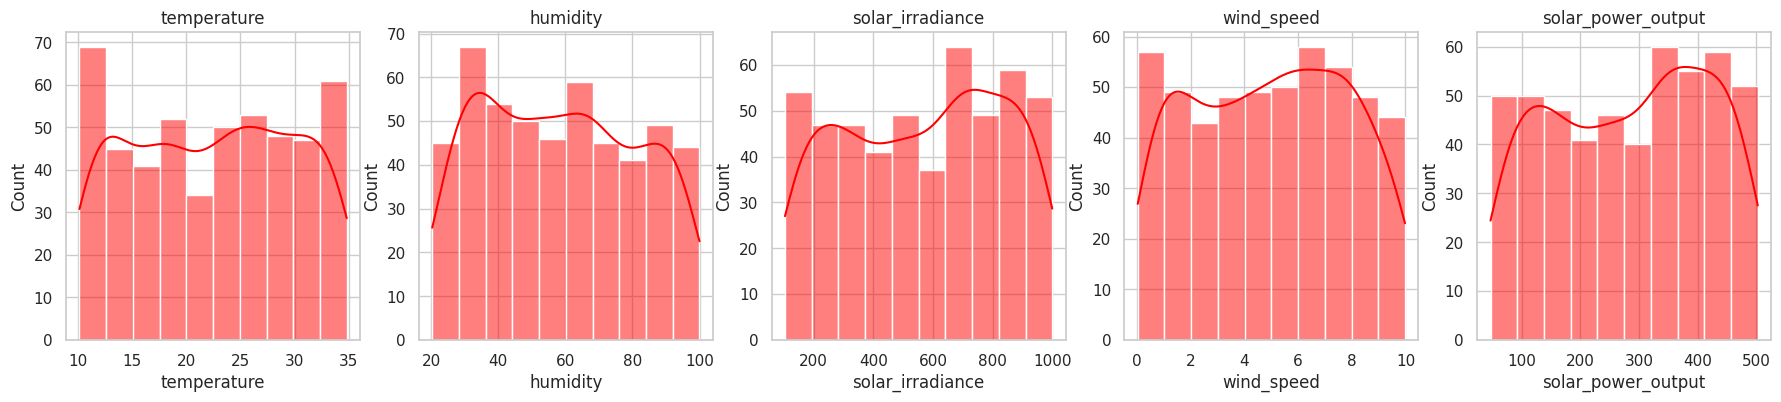

In [17]:
fig, axes =plt.subplots(1,5, figsize=(22,4))
for ax, col in zip(axes, df.columns):
  sns.histplot(df[col],kde=True, ax=ax, color="red")
  ax.set_title(col)
plt.show()

3.2 Bivariate analysis- checking the variables btw x and y

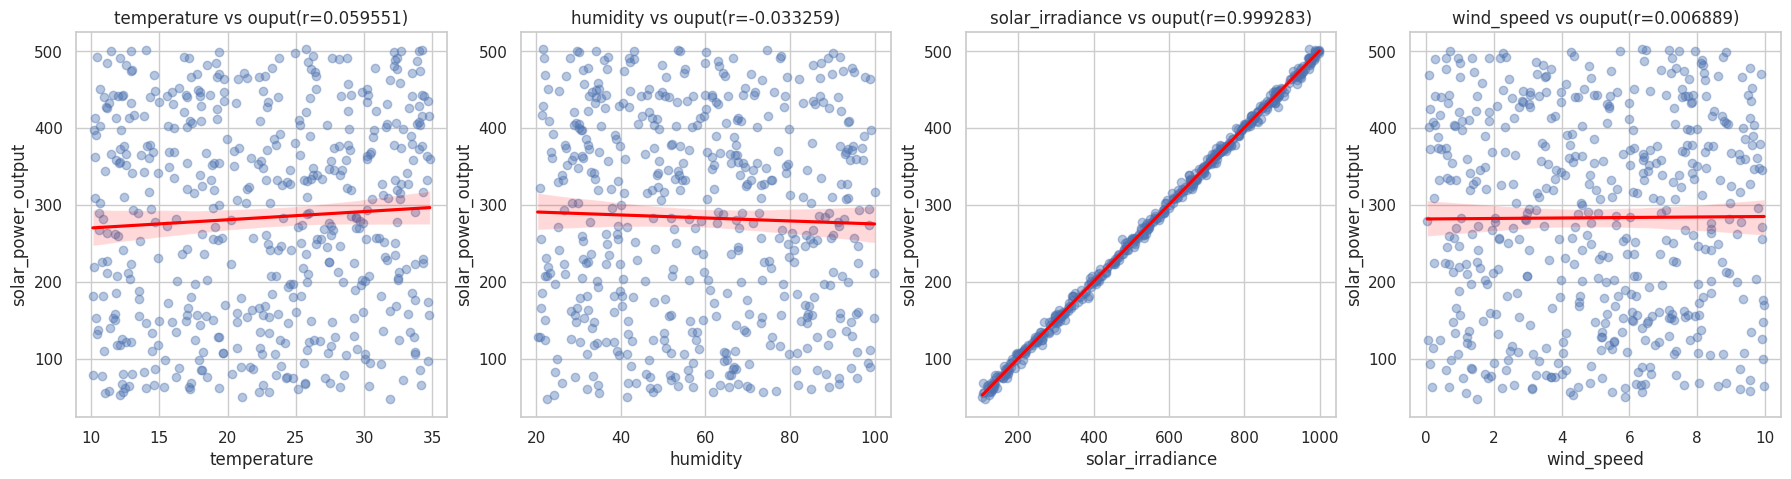

In [20]:
features =["temperature", "humidity","solar_irradiance","wind_speed"]
fig,axes=plt.subplots(1, 4, figsize=(22,5))
for ax,col in zip(axes, features):
  sns.regplot(x=df[col],y=df["solar_power_output"],ax=ax,scatter_kws={"alpha":0.4},line_kws={"color":"red"})
  r=df[col].corr(df["solar_power_output"])
  ax.set_title(f"{col} vs ouput(r={r:3f})")
plt.show()

3.3 multivaraiant analysis:best

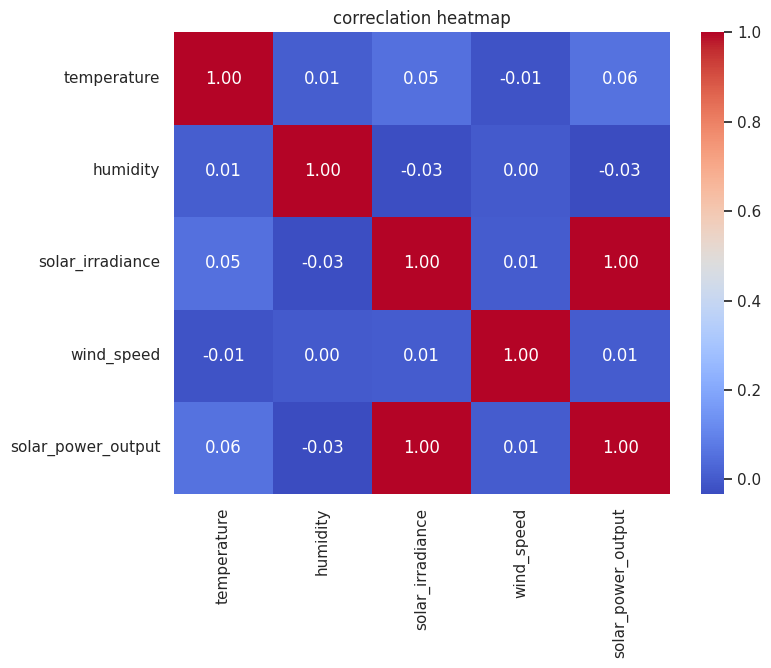

In [24]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("correclation heatmap")
plt.show()

4.Data preprocessing/data cleaning:-to check the null value we will use the code =df.isnull().sum()

In [25]:
df.isnull().sum()

,0
temperature,0
humidity,0
solar_irradiance,0
wind_speed,0
solar_power_output,0


In [26]:
df.duplicated().sum()

np.int64(0)

taking variable for model building

In [27]:
x=df["solar_irradiance"]
y=df["solar_power_output"]

data splitiing

In [30]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


algorithm selection--> simple linear regression

7. Model =Linear Regression

In [39]:
model=LinearRegression()
model.fit(x_train.values.reshape(-1, 1), y_train)
print("slope:", model.coef_[0])
print("intercept:", model.intercept_)

slope: 0.5005361509109775
intercept: 0.010596780972093711


final model evaluation

In [45]:
y_pred=model.predict(x_test.values.reshape(-1, 1))
print("R2 score:", r2_score(y_test, y_pred))
print("mean absolute error:", mean_absolute_error(y_test, y_pred))
print("mean squared error:", mean_squared_error(y_test, y_pred))

R2 score: 0.9981624336592926
mean absolute error: 4.272564495023546
mean squared error: 32.33319189996614


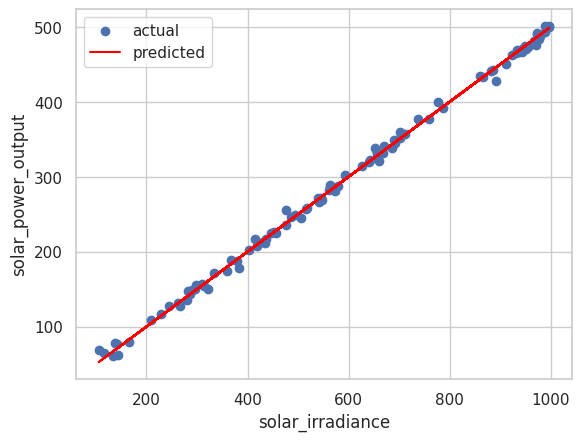

In [46]:
plt.scatter(x_test,y_test,label="actual")
plt.plot(x_test,y_pred,color="red",label="predicted")
plt.xlabel("solar_irradiance")
plt.ylabel("solar_power_output")
plt.legend()
plt.show()

save teh model for deployment

In [48]:
joblib.dump(model,"model.pkl")
print("model saved")

model saved
